In [11]:
import json
import os
import time

import numpy as np
import pandas as pd
from tqdm import tqdm

from analysis import landmark_analysis, geomorph
from config import update_config
from config_loader import get_config
from predictor import prediction
from transform import (
    image_processing,
    landmark_processing,
    segmentation_processing,
    wing_processing,
)
import utils

import matplotlib.pyplot as plt
import skimage as ski

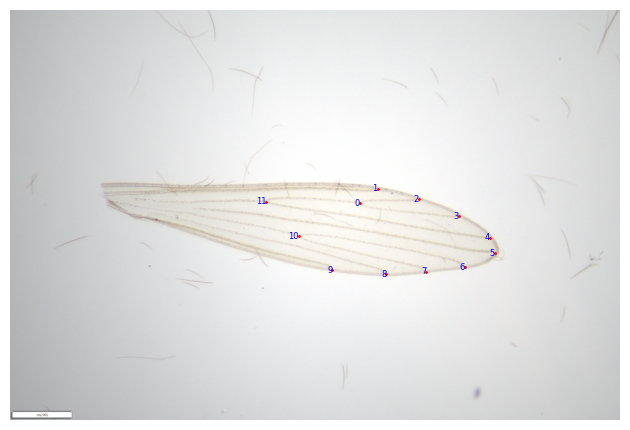

In [16]:
df = pd.read_csv("training/data_psycho/landmark/landmark_annotations_benin.csv", sep=";")
filename = "psychodidae_benin-sandfly-sampling_m_l_1b6c687c4619.tif"
image = plt.imread(os.path.join("training/data_psycho/landmark/image_raw", filename))

X_cols = [col for col in df.columns if col.startswith("X")]
Y_cols = [col for col in df.columns if col.startswith("Y")]

X = df[df["filename"] == filename][X_cols].values[0]
Y = df[df["filename"] == filename][Y_cols].values[0]

plt.imshow(image)
plt.scatter(X, Y, c="red", marker="o", s=1)

# Add text labels for each point based on the column names
for i, (x, y) in enumerate(zip(X, Y)):
    plt.text(x, y, f"{X_cols[i][1:]}".replace("_", ""), fontsize=6, color="blue", ha="right", va="center")

plt.axis("off")
plt.tight_layout()

In [12]:
def run_prediction(file, save_path, family, timing_info=None, stream=True, save_image=True, num_landmarks_ref="default"):
    
    # Update global CONFIG for this family (so transform modules use correct config)
    update_config(family)

    image_aligned, mask_aligned, mask = image_processing.process_image(file, from_stream=False)

    image_ithildin = image_processing.transform_image(
        image_aligned,
        mask_aligned,
        contrast="Soft",
        resize_size=640,
    )

    # 1) Contrast stretching
    p2, p98 = np.percentile(image_ithildin, (2, 98))
    image_ithildin_streched = exposure.rescale_intensity(image_ithildin, in_range=(p2, p98))

    segmentation_sigmoid, segmentation_logit = prediction.run_segmentation(image_ithildin_streched, family)
    
    segmentation_sigmoid_png = np.uint8(segmentation_sigmoid * 255)
    image_ithildin_streched_png = np.uint8(image_ithildin_streched * 255)

    ski.io.imsave(save_path, segmentation_sigmoid_png)
    ski.io.imsave(save_path.replace("segmentation_frommodel", "image_processed"), image_ithildin_streched_png)

In [14]:
file_list = os.listdir("training/data_psycho/segmentation/image_raw/")
file_list = [f for f in file_list if f.endswith(".tif") and not f.startswith(".")]

for file_name in tqdm(file_list):
    file = f"training/data_psycho/segmentation/image_raw/{file_name}"
    save_path = f"training/data_psycho/segmentation/segmentation_frommodel/{file_name}"
    family = "psychodidae"
    run_prediction(file, save_path, family)

100%|██████████| 548/548 [38:07<00:00,  4.17s/it]
